# Tutorial 1: from a neuron to backprop, built by hand
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T01_neurons_to_backprop.ipynb) · [Recap slides](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T01_neurons_to_backprop_recap.pdf)

Plan for today (≈ 75 min):
0. Recap slides (15 min)
1. Lecture recap: neuron, perceptron, XOR, MLP, chain rule (10 min)
2. A perceptron, and why it fails on XOR (5 min)
3. A scalar autograd engine in ~40 lines (20 min)
4. The same MLP with tensors: manual backward vs `torch.autograd` (15 min)
5. Initial weights: why the scale of the random start matters (10 min)
6. If time: BatchNorm by hand, and the library version of everything

Runs on CPU (Colab or laptop). Cells marked ✏️ are for you to try.

In [1]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0); random.seed(0); np.random.seed(0)

## 1. Lecture recap

**Neuron.** Input $x\in\mathbb{R}^d$, weights $w\in\mathbb{R}^d$, bias $b$: $\;\hat y = \sigma(w^\top x + b)$.

**Perceptron (Rosenblatt, 1958).** Step activation, labels $y\in\{0,1\}$, update on every example
$$\Delta w = \eta\,(y-\hat y)\,x .$$
No change when correct; when wrong, the hyperplane moves toward the misclassified point. It converges iff the data is linearly separable.

**XOR (Minsky & Papert, 1969).** No single hyperplane separates XOR → one hidden layer fixes it, but now we need a way to train the hidden weights.

**Training an MLP** = minimize a loss $L(\theta)$ by gradient descent, $\theta \leftarrow \theta - \eta \nabla_\theta L$.

**Backprop** = the chain rule on the computational graph. Every node only needs its *local* gradient:
$$\underbrace{\frac{\partial L}{\partial x}}_{\text{downstream}} = \underbrace{\frac{\partial z}{\partial x}}_{\text{local}} \cdot \underbrace{\frac{\partial L}{\partial z}}_{\text{upstream}}$$
Patterns: **add** copies the upstream gradient to both inputs; **mul** swaps the inputs; **max** routes it to the winner; a node used twice **sums** its gradients.

## 2. Perceptron, and the XOR wall

In [2]:
def perceptron(X, y, epochs=20, lr=1.0):
    w, b = np.zeros(X.shape[1]), 0.0
    for _ in range(epochs):
        for xi, yi in zip(X, y):
            y_hat = float(w @ xi + b > 0)
            w += lr * (yi - y_hat) * xi
            b += lr * (yi - y_hat)
    return w, b

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
for name, y in [("AND", np.array([0,0,0,1.])), ("OR", np.array([0,1,1,1.])), ("XOR", np.array([0,1,1,0.]))]:
    w, b = perceptron(X, y)
    acc = ((X @ w + b > 0) == y).mean()
    print(f"{name}: w={w}, b={b:+.0f}, accuracy={acc:.2f}")

AND: w=[2. 1.], b=-2, accuracy=1.00
OR: w=[1. 1.], b=+0, accuracy=1.00
XOR: w=[-1.  0.], b=+1, accuracy=0.50


AND and OR are learned exactly. On XOR the weights keep cycling and accuracy never reaches 1, however many epochs we give it (at best 3 of 4 points; here it ends at 2 of 4). We need a hidden layer, and therefore gradients through it.

## 3. A scalar autograd engine

Each `Value` stores its number, its gradient, its parents, and a closure that applies the **local gradient × upstream** rule.
`backward()` visits the graph in reverse topological order, so every node has its full upstream gradient before it passes it on.

In [3]:
class Value:
    def __init__(self, data, parents=()):
        self.data, self.grad = float(data), 0.0
        self._parents, self._backward = parents, lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))
        def _backward():                      # add: distribute
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))
        def _backward():                      # mul: swap
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,))
        def _backward():
            self.grad += (1 - t * t) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,))
        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):                     # k is a plain number
        out = Value(self.data ** k, (self,))
        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward
        return out

    __radd__ = __add__
    __rmul__ = __mul__
    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)

    def backward(self):
        order, seen = [], set()
        def visit(v):
            if v not in seen:
                seen.add(v)
                for p in v._parents: visit(p)
                order.append(v)
        visit(self)
        self.grad = 1.0
        for v in reversed(order):
            v._backward()

    def __repr__(self): return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

**Check 1: the sigmoid neuron from the backprop lecture.** $f = \sigma(w_0x_0 + w_1x_1 + w_2)$ with $w_0=2, x_0=-1, w_1=-3, x_1=-2, w_2=-3$. The lecture got $f=0.73$ and a local sigmoid gradient of $(1-0.73)\cdot 0.73 = 0.20$.

In [4]:
w0, x0, w1, x1, w2 = Value(2.0), Value(-1.0), Value(-3.0), Value(-2.0), Value(-3.0)
f = (w0 * x0 + w1 * x1 + w2).sigmoid()
f.backward()
print(f"f = {f.data:.2f}")
print(f"df/dw0 = {w0.grad:.2f}, df/dx0 = {x0.grad:.2f}, df/dw1 = {w1.grad:.2f}, df/dx1 = {x1.grad:.2f}, df/dw2 = {w2.grad:.2f}")

# same graph in PyTorch
t = {k: torch.tensor(v, requires_grad=True) for k, v in dict(w0=2., x0=-1., w1=-3., x1=-2., w2=-3.).items()}
torch.sigmoid(t['w0'] * t['x0'] + t['w1'] * t['x1'] + t['w2']).backward()
print("torch:   ", {k: round(v.grad.item(), 2) for k, v in t.items()})

f = 0.73
df/dw0 = -0.20, df/dx0 = 0.39, df/dw1 = -0.39, df/dx1 = -0.59, df/dw2 = 0.20
torch:    {'w0': -0.2, 'x0': 0.39, 'w1': -0.39, 'x1': -0.59, 'w2': 0.2}


✏️ **Why `+=` and not `=` in every `_backward`?** Try `a = Value(3.0); b = a * a; b.backward()` with `=` instead. A node used twice must sum its gradients.

In [5]:
a = Value(3.0); b = a * a; b.backward()
print(a.grad, "(should be d(a^2)/da = 6)")

6.0 (should be d(a^2)/da = 6)


**Check 2: an MLP made of `Value`s learns XOR**, the function the perceptron could not.

In [6]:
class Neuron:
    def __init__(self, n_in):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(n_in)]
        self.b = Value(0.0)
    def __call__(self, x):
        return sum((wi * xi for wi, xi in zip(self.w, x)), self.b).tanh()
    def params(self): return self.w + [self.b]

class MLP:
    def __init__(self, sizes):
        self.layers = [[Neuron(a) for _ in range(b)] for a, b in zip(sizes[:-1], sizes[1:])]
    def __call__(self, x):
        for layer in self.layers:
            x = [n(x) for n in layer]
        return x[0] if len(x) == 1 else x
    def params(self): return [p for layer in self.layers for n in layer for p in n.params()]

random.seed(1)
net = MLP([2, 4, 1])
X_xor = [[0, 0], [0, 1], [1, 0], [1, 1]]
y_xor = [-1, 1, 1, -1]                      # tanh output, so targets in {-1, +1}

for step in range(200):
    loss = sum(((net(x) - y) ** 2 for x, y in zip(X_xor, y_xor)), Value(0.0))
    for p in net.params(): p.grad = 0.0     # zero grads, or they accumulate across steps
    loss.backward()
    for p in net.params(): p.data -= 0.05 * p.grad
    if step % 50 == 0 or step == 199:
        print(f"step {step:3d}  loss {loss.data:.4f}")

print("predictions:", [round(net(x).data, 2) for x in X_xor], "targets:", y_xor)

step   0  loss 4.1022
step  50  loss 0.3214
step 100  loss 0.0862
step 150  loss 0.0457
step 199  loss 0.0305
predictions: [-0.93, 0.91, 0.91, -0.91] targets: [-1, 1, 1, -1]


## 4. The same thing with tensors: manual backward

A 2-layer MLP for 10-class classification, written as matrix ops:
$$h = \mathrm{ReLU}(XW_1 + b_1),\qquad s = hW_2 + b_2,\qquad L = \tfrac{1}{N}\textstyle\sum_i -\log \mathrm{softmax}(s_i)_{y_i}.$$
Backward, using the same local × upstream rule but with matrices (shapes must match the forward):
$$\frac{\partial L}{\partial s} = \tfrac{1}{N}(\mathrm{softmax}(s) - Y),\quad
\frac{\partial L}{\partial W_2} = h^\top \frac{\partial L}{\partial s},\quad
\frac{\partial L}{\partial h} = \frac{\partial L}{\partial s} W_2^\top,\quad
\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial h}\odot \mathbb{1}[a_1>0],\quad
\frac{\partial L}{\partial W_1} = X^\top \frac{\partial L}{\partial a_1}.$$

In [7]:
N, D, H, C = 64, 20, 32, 10
X = torch.randn(N, D, dtype=torch.float64)
y = torch.randint(0, C, (N,))
W1 = (torch.randn(D, H, dtype=torch.float64) * 0.1).requires_grad_()
b1 = torch.zeros(H, dtype=torch.float64, requires_grad=True)
W2 = (torch.randn(H, C, dtype=torch.float64) * 0.1).requires_grad_()
b2 = torch.zeros(C, dtype=torch.float64, requires_grad=True)

# forward
a1 = X @ W1 + b1
h = a1.clamp(min=0)
s = h @ W2 + b2
loss = F.cross_entropy(s, y)

# manual backward
with torch.no_grad():
    ds = (torch.softmax(s, 1) - F.one_hot(y, C)) / N
    dW2, db2 = h.T @ ds, ds.sum(0)
    dh = ds @ W2.T
    da1 = dh * (a1 > 0)
    dW1, db1 = X.T @ da1, da1.sum(0)

# autograd
loss.backward()
for name, mine, ref in [("W1", dW1, W1.grad), ("b1", db1, b1.grad), ("W2", dW2, W2.grad), ("b2", db2, b2.grad)]:
    print(f"{name}: max |manual − autograd| = {(mine - ref).abs().max().item():.2e}")

W1: max |manual − autograd| = 6.94e-18
b1: max |manual − autograd| = 3.47e-18
W2: max |manual − autograd| = 1.39e-17
b2: max |manual − autograd| = 2.78e-17


✏️ Add a `tanh` layer between `h` and `s` and extend the manual backward. Which single line changes?

**Past exam question (Moed B, 2026)**

True or false: in a binary classification task, one can use accuracy as the training loss, optimized with gradients, instead of binary cross-entropy, and thus obtain better results when accuracy is the only metric of interest.

**False.** Accuracy is piecewise constant in the parameters: an infinitesimal change of $w$ or $b$ flips no prediction, so its gradient is 0 almost everywhere (and undefined at the jumps). Gradient descent gets no signal. BCE is a smooth surrogate whose gradient is non-zero even for correctly classified points. The check below scans the bias of a 1-D logistic classifier.

accuracy has a grad_fn? False
d accuracy / db ≈ 0.000    d BCE / db = 0.086


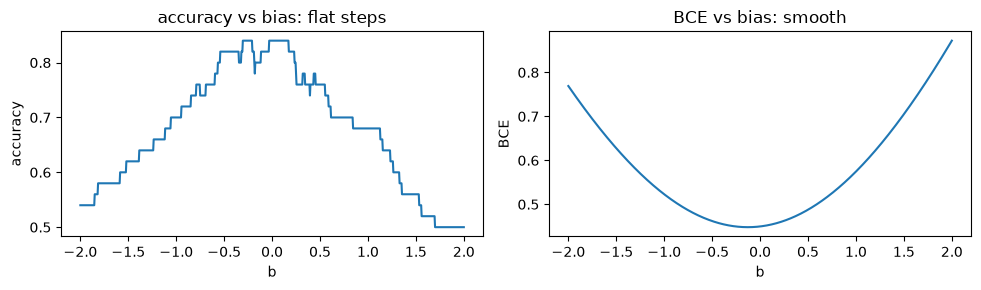

In [8]:
g_acc = torch.Generator().manual_seed(0)
x_acc = torch.randn(50, generator=g_acc)
y_acc = (x_acc + 0.5 * torch.randn(50, generator=g_acc) > 0).float()
acc_of_bias = lambda b: ((x_acc + b > 0).float() == y_acc).float().mean()
b0 = torch.tensor(0.3, requires_grad=True)
print("accuracy has a grad_fn?", acc_of_bias(b0).grad_fn is not None)       # the comparison cuts the graph
acc_fd = (acc_of_bias(0.3 + 1e-4) - acc_of_bias(0.3 - 1e-4)) / 2e-4
bce_grad, = torch.autograd.grad(F.binary_cross_entropy_with_logits(x_acc + b0, y_acc), b0)
print(f"d accuracy / db ≈ {acc_fd.item():.3f}    d BCE / db = {bce_grad.item():.3f}")

bs = torch.linspace(-2, 2, 801)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(bs, [acc_of_bias(b).item() for b in bs]); ax[0].set(title="accuracy vs bias: flat steps", xlabel="b", ylabel="accuracy")
ax[1].plot(bs, [F.binary_cross_entropy_with_logits(x_acc + b, y_acc).item() for b in bs]); ax[1].set(title="BCE vs bias: smooth", xlabel="b", ylabel="BCE")
plt.tight_layout(); plt.show()

## 5. Initial weights

**Background.** In 2006 the "deep learning" revival (Hinton & Salakhutdinov, lecture 1) trained deep nets by **layer-wise unsupervised pretraining** first, because deep nets trained from a random start mostly failed. Four years later, Glorot & Bengio (2010) showed that a large part of the failure was simply **the scale of the random initial weights**. Then He et al. (2015) derived the right scale for ReLU and trained a 30-layer plain network from scratch. Nobody pretrains for this reason anymore. The fix is one line: choose the init std.

**Why scale matters.** For a layer $a = Wx$ with $n_{in}$ inputs and i.i.d. weights of variance $\sigma^2$, $\;\mathrm{Var}(a) \approx n_{in}\,\sigma^2\,\mathrm{Var}(x)$. Over $L$ layers this multiplies $L$ times, so the activations (and the gradients going back) **explode** if $n_{in}\sigma^2 > 1$ and **vanish** if it is $< 1$.
- Xavier/Glorot (tanh): $\sigma^2 = 1/n_{in}$ (or $2/(n_{in}+n_{out})$)
- Kaiming/He (ReLU kills half the signal): $\sigma^2 = 2/n_{in}$

Let's see it: 10 layers, width 512; three choices of std with tanh, two with ReLU.

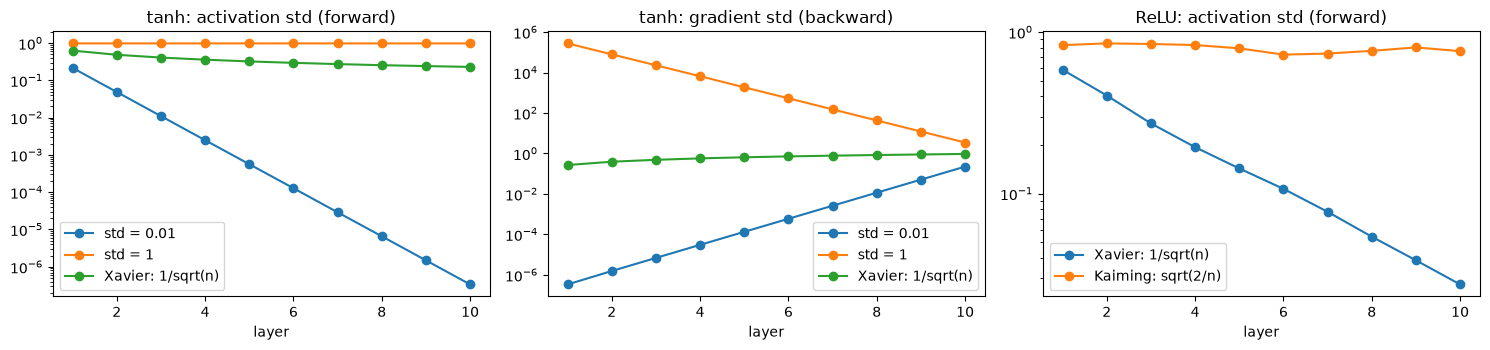

In [9]:
def signal_stats(std_fn, depth=10, width=512, act=torch.tanh):
    # per-layer activation std (forward) and std of dL/d(layer input) (backward)
    x = torch.randn(1000, width)
    inputs, acts = [], []
    for _ in range(depth):
        x = x.detach().requires_grad_() if not inputs else x
        x.retain_grad(); inputs.append(x)
        W = torch.randn(width, width) * std_fn(width)
        x = act(x @ W)
        acts.append(x.std().item())
    x.backward(torch.randn_like(x))
    grads = [t.grad.std().item() for t in inputs]
    return acts, grads

inits = {
    "std = 0.01":              lambda n: 0.01,
    "std = 1":                 lambda n: 1.0,
    "Xavier: 1/sqrt(n)":       lambda n: 1 / math.sqrt(n),
}
layers = range(1, 11)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for name, fn in inits.items():
    acts, grads = signal_stats(fn)
    axes[0].plot(layers, acts, marker="o", label=name)
    axes[1].plot(layers, grads, marker="o", label=name)
axes[0].set(title="tanh: activation std (forward)", xlabel="layer", yscale="log"); axes[0].legend()
axes[1].set(title="tanh: gradient std (backward)", xlabel="layer", yscale="log"); axes[1].legend()

relu_inits = {"Xavier: 1/sqrt(n)": lambda n: 1 / math.sqrt(n), "Kaiming: sqrt(2/n)": lambda n: math.sqrt(2 / n)}
for name, fn in relu_inits.items():
    axes[2].plot(layers, signal_stats(fn, act=torch.relu)[0], marker="o", label=name)
axes[2].set(title="ReLU: activation std (forward)", xlabel="layer", yscale="log"); axes[2].legend()
plt.tight_layout(); plt.show()

- **std = 0.01**: activations shrink by ~$\sqrt{512}\cdot 0.01 \approx 0.23$ per layer and are ~$10^{-6}$ by layer 10. Gradients shrink the same way going back (middle plot), so the first layers barely learn.
- **std = 1**: $\sqrt{512}\approx 23$× too large. The forward plot *looks* fine (std ≈ 1), but only because the tanh units are saturated at ±1. The backward plot shows the problem: going back, each layer multiplies the gradient by $W^\top$ (≈23× too large) and by $1-\tanh^2$ (small for most units), and the product still grows, so layer 1 gets gradients ~$10^5$× larger than layer 10. One learning rate cannot suit both ends. Always look at both directions.
- **Xavier** keeps tanh stable; with ReLU it halves the variance each layer; **Kaiming**'s factor 2 fixes exactly that.

**And zero init?** Then every hidden unit computes the same function, receives the same gradient, and stays identical forever. Initial weights must be random to break the symmetry.

In [10]:
torch.manual_seed(0)
net0 = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1))
for p in net0.parameters():
    nn.init.constant_(p, 0.3)                 # identical (non-zero) start for every unit
opt = torch.optim.SGD(net0.parameters(), lr=0.1)
Xt = torch.tensor([[0., 0], [0, 1], [1, 0], [1, 1]]); yt = torch.tensor([[-1.], [1], [1], [-1]])
for _ in range(500):
    opt.zero_grad(); F.mse_loss(net0(Xt), yt).backward(); opt.step()
print("hidden-layer weights after 500 steps (all rows identical):\n", net0[0].weight.data)
print("XOR predictions:", net0(Xt).squeeze().detach().numpy().round(2))

hidden-layer weights after 500 steps (all rows identical):
 tensor([[1.3095, 1.3095],
        [1.3095, 1.3095],
        [1.3095, 1.3095],
        [1.3095, 1.3095]])
XOR predictions: [-0.79  0.24  0.24  0.35]


✏️ Re-run the XOR `Value`-MLP from section 3 with `random.uniform(-1, 1)` replaced by `random.uniform(-0.001, 0.001)` and then by `random.uniform(-10, 10)`. What happens to the loss curve, and why?

PyTorch's `nn.Linear` already initializes with a Kaiming-style uniform scale, which is why "it just works" by default.

**Past exam question (Moed C, 2026)**

A researcher plans to train a very deep network (50 layers) of fully connected layers, with a sigmoid activation in every layer and random weights drawn from the standard normal distribution $\mathcal{N}(0,1)$. He finds that training barely progresses and the loss does not go down.

Explain what happens in the **forward** and in the **backward** pass, and propose **two concrete changes** (one to the initialization, one to the architecture / activation function) that can fix the problem. Explain why each change helps.

sigmoid, N(0,1)  (the exam)    grad std layer 1 / layer 50 = 3.1e+04   saturated units: layer 1 77%, layer 50 69%


sigmoid, Xavier 1/sqrt(n)      grad std layer 1 / layer 50 = 1.6e-31   saturated units: layer 1 0%, layer 50 0%


sigmoid, 4 × Xavier            grad std layer 1 / layer 50 = 9.5e-11   saturated units: layer 1 25%, layer 50 7%


tanh, Xavier                   grad std layer 1 / layer 50 = 1.2e-01   


ReLU, Kaiming sqrt(2/n)        grad std layer 1 / layer 50 = 7.6e-01   


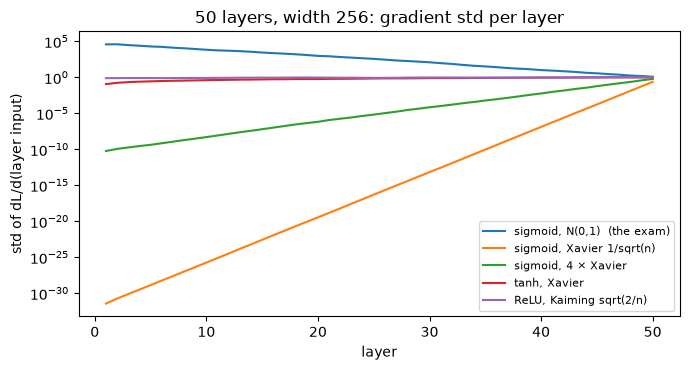

In [11]:
def deep_stats(std, act, depth=50, width=256):
    # per layer: fraction of saturated units (sigmoid(z) < 0.01 or > 0.99) and std of dL/d(layer input)
    torch.manual_seed(0)
    x = torch.randn(512, width, requires_grad=True)
    inputs, sat = [], []
    for _ in range(depth):
        x.retain_grad(); inputs.append(x)
        z = x @ (torch.randn(width, width) * std)
        x = act(z)
        s = torch.sigmoid(z)
        sat.append(((s < 0.01) | (s > 0.99)).float().mean().item())
    x.backward(torch.randn_like(x))
    return sat, [t.grad.std().item() for t in inputs]

n_w = 256
settings = {
    "sigmoid, N(0,1)  (the exam)": (1.0, torch.sigmoid),
    "sigmoid, Xavier 1/sqrt(n)":   (1 / math.sqrt(n_w), torch.sigmoid),
    "sigmoid, 4 × Xavier":         (4 / math.sqrt(n_w), torch.sigmoid),
    "tanh, Xavier":                (1 / math.sqrt(n_w), torch.tanh),
    "ReLU, Kaiming sqrt(2/n)":     (math.sqrt(2 / n_w), torch.relu),
}
fig, ax = plt.subplots(figsize=(7, 3.8))
for name, (std, act) in settings.items():
    sat, g = deep_stats(std, act, width=n_w)
    ax.semilogy(range(1, 51), g, label=name)
    sat_txt = f"saturated units: layer 1 {sat[0]:.0%}, layer 50 {sat[-1]:.0%}" if act is torch.sigmoid else ""
    print(f"{name:30s} grad std layer 1 / layer 50 = {g[0] / g[-1]:.1e}   {sat_txt}")
ax.set(title="50 layers, width 256: gradient std per layer", xlabel="layer", ylabel="std of dL/d(layer input)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Forward.** With $\mathcal{N}(0,1)$ weights and $n$ inputs per unit, $\mathrm{Var}(z) = n\,\mathbb{E}[a^2]$. Sigmoid outputs are positive ($\mathbb{E}[a^2]\approx 0.3$–$0.5$), so $\mathrm{std}(z)\approx 10$ at width 256: most units sit in the flat tails of the sigmoid (the run: ~70–77% saturated), and every layer outputs an almost binary pattern.

**Backward.** Every layer multiplies the gradient by $W^\top\mathrm{diag}(\sigma'(z))$, with $\sigma'\le 1/4$ and $\sigma'\approx 0$ on saturated units. The official solution says the product vanishes exponentially. That is true for narrow layers, but at width 256 the run shows the opposite: the $\mathcal{N}(0,1)$ weights are $\sqrt n$ times too large and outweigh the small $\sigma'$, so layer 1 receives a gradient ~$10^4$ times larger than layer 50. The per-layer factor is roughly $\sqrt{n\,\mathbb{E}[\sigma'(z)^2]}\approx 0.09\sqrt n$: the gradient vanishes for $n\lesssim 100$ and explodes for wider layers. Either way the gradient scale differs by orders of magnitude between layers, most units pass almost no gradient, and no single learning rate trains the network.

**Fix 1 (initialization):** scale the weights with the fan-in, $\sigma^2\propto 1/n_{in}$ (Xavier/Glorot), which removes the saturation. **Plain Xavier is not enough for sigmoid, though:** in the run the gradient at layer 1 is ~$10^{-31}$ of layer 50, because $\sigma'(0)=1/4$ shrinks it ~4× per layer. Xavier assumes an activation with slope 1 at 0 (tanh). Glorot & Bengio use 4× larger weights for sigmoid; that improves it to ~$10^{-10}$, still unusable at depth 50.
**Fix 2 (activation / architecture):** ReLU with Kaiming init $\sigma^2=2/n_{in}$ (derivative 1 on the active side, no saturation), or tanh with Xavier. In the run the gradient std changes by less than 10× over all 50 layers with either. Residual connections, or BatchNorm/LayerNorm after each layer, also work: they keep the signal scale fixed whatever the initialization.

## 6. If time: BatchNorm by hand

The other fix for bad scaling: normalize each feature over the batch, then let the network rescale it,
$$\hat x = \frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\qquad y = \gamma \hat x + \beta .$$
Backward (derive it on the board from the graph; three paths reach $x$: directly, through $\mu_B$, and through $\sigma_B^2$):
$$\frac{\partial L}{\partial x} = \frac{\gamma}{N\sqrt{\sigma_B^2+\epsilon}}\Big(N\,\frac{\partial L}{\partial y} - \sum_i \frac{\partial L}{\partial y_i} - \hat x \sum_i \frac{\partial L}{\partial y_i}\hat x_i\Big)$$

In [12]:
def batchnorm_forward(x, gamma, beta, eps=1e-5):
    mu, var = x.mean(0), x.var(0, unbiased=False)
    x_hat = (x - mu) / torch.sqrt(var + eps)
    return gamma * x_hat + beta, (x_hat, var, eps)

def batchnorm_backward(dy, gamma, cache):
    x_hat, var, eps = cache
    N = dy.shape[0]
    dgamma, dbeta = (dy * x_hat).sum(0), dy.sum(0)
    dx = gamma / (N * torch.sqrt(var + eps)) * (N * dy - dy.sum(0) - x_hat * (dy * x_hat).sum(0))
    return dx, dgamma, dbeta

x = torch.randn(32, 8, dtype=torch.float64, requires_grad=True)
gamma = torch.rand(8, dtype=torch.float64, requires_grad=True)
beta = torch.randn(8, dtype=torch.float64, requires_grad=True)
y_bn, cache = batchnorm_forward(x, gamma, beta)
dy = torch.randn_like(y_bn)
y_bn.backward(dy)
dx, dgamma, dbeta = batchnorm_backward(dy, gamma.detach(), tuple(c.detach() if torch.is_tensor(c) else c for c in cache))
print("dx     max err:", (dx - x.grad).abs().max().item())
print("dgamma max err:", (dgamma - gamma.grad).abs().max().item())
print("dbeta  max err:", (dbeta - beta.grad).abs().max().item())

dx     max err: 2.220446049250313e-16
dgamma max err: 0.0
dbeta  max err: 0.0


**Past exam question (Moed B, 2026)**

Given a BatchNorm block $\hat{x} = \dfrac{x - \mu}{\sqrt{\sigma^2 + \epsilon}},\; y = \gamma \hat{x} + \beta$. Which of the following statements about $\gamma$ and $\beta$ are true? (More than one may be correct.)
1. $\gamma$ and $\beta$ are learned parameters that apply an affine transformation after the normalization.
2. There are values of $\gamma$ and $\beta$ for which the block implements the identity mapping.
3. Removing $\gamma$ and $\beta$ does not change at all the space of functions the network can represent.
4. $\gamma$ and $\beta$ affect the statistics $\mu$ and $\sigma^2$ computed during training.

**1 and 2.** (1) by definition. (2) $\gamma=\sqrt{\sigma^2+\epsilon}$, $\beta=\mu$ undo the normalization; in eval mode, with the running statistics, this is an exact identity (check below); in training mode it is exact only for the batch whose statistics were used, since $\mu_B,\sigma_B$ change from batch to batch. (3) is false: without them every BN output has mean 0 and variance 1 per feature, e.g. a following sigmoid is confined to its near-linear range. (4) is false: $\mu,\sigma^2$ are computed from $x$, before $\gamma,\beta$ are applied.

In [13]:
torch.manual_seed(0)
bn = nn.BatchNorm1d(8)
xb = torch.randn(64, 8) * 3 + 2
with torch.no_grad():
    for _ in range(200):
        bn(xb)                                   # training mode: the running statistics converge to this batch's
bn.eval()
with torch.no_grad():
    bn.weight.copy_(torch.sqrt(bn.running_var + bn.eps)); bn.bias.copy_(bn.running_mean)
print("eval-mode BN with γ = sqrt(running_var + eps), β = running_mean:  max |BN(x) − x| =", (bn(xb) - xb).abs().max().item())

eval-mode BN with γ = sqrt(running_var + eps), β = running_mean:  max |BN(x) − x| = 9.5367431640625e-07


**Past exam question (Moed C, 2026)**

In LayerNorm the mean and variance are computed **for each example separately**, over the feature dimension; in BatchNorm they are computed over the batch dimension, for each feature separately. A Transformer with LayerNorm was trained for machine translation. At inference we translate a single sentence (batch size 1).

Explain why in this case LayerNorm behaves exactly as in training, whereas BatchNorm would need a special mechanism (such as running statistics). Refer to how the statistics are computed in each case.

**LayerNorm:** $\mu,\sigma^2$ are taken over the $d$ features of each token, so they depend only on that token. A batch of 1 gives exactly the same output as the same sentence inside a training batch (check below: difference 0).
**BatchNorm:** $\mu,\sigma^2$ of each feature are taken over the batch. With one example, $x-\mu_B=0$ and $\sigma_B^2=0$, so every output equals $\beta$ whatever the input; PyTorch refuses to run it in training mode. The output for one example also depends on which other examples share its batch. At inference BN therefore switches to running averages of $\mu,\sigma^2$ collected during training, a second code path whose statistics can drift from what the model saw (the official solution says the normalization is undefined at batch size 1; with $\epsilon>0$ it is defined but erases the input).

In [14]:
torch.manual_seed(0)
d = 16
batch = torch.randn(8, 5, d)                     # 8 sentences, 5 tokens, d features
one = batch[:1]                                  # translate one sentence alone
ln = nn.LayerNorm(d, elementwise_affine=False)
my_ln = lambda z: (z - z.mean(-1, keepdim=True)) / torch.sqrt(z.var(-1, unbiased=False, keepdim=True) + ln.eps)
print("my LN vs nn.LayerNorm:                       ", (my_ln(batch) - ln(batch)).abs().max().item())
print("LN, sentence alone vs inside the batch:      ", (ln(one) - ln(batch)[:1]).abs().max().item())

bn = nn.BatchNorm1d(d).train()
flat = batch.reshape(-1, d)                      # BN over all tokens of the batch, per feature
x1 = one[0, :1]                                  # a single example
try:
    bn(x1)
except ValueError as e:
    print("BN, single example, train mode → ValueError:", e)
print("by hand, single example: max |x − μ_B| =", (x1 - x1.mean(0)).abs().max().item(), "→ output = β for any input")
print("BN, sentence alone vs inside the batch:      ", (bn(one[0]) - bn(flat)[:5]).abs().max().item())

my LN vs nn.LayerNorm:                        2.384185791015625e-07
LN, sentence alone vs inside the batch:       0.0
BN, single example, train mode → ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 16])
by hand, single example: max |x − μ_B| = 0.0 → output = β for any input
BN, sentence alone vs inside the batch:       1.5463874340057373


## Summary
- The perceptron rule learns any linearly separable function and nothing else; XOR needs a hidden layer.
- Backprop is just **local gradient × upstream gradient**, applied in reverse topological order, with **+=** for nodes that are reused.
- Manual matrix gradients match `torch.autograd` to ~1e-16: autograd is not magic, it is section 3 with tensors.
- **Initial weights** set the scale of every signal in the network: too small → vanishing, too large → saturation or explosion, all equal → symmetric units. Xavier (tanh) and Kaiming (ReLU) choose $\sigma^2 \propto 1/n_{in}$.

**Further watching:** Karpathy, *The spelled-out intro to neural networks and backpropagation: building micrograd* (section 3 follows it); Karpathy, *makemore part 3* (initialization and BatchNorm).